# Brain MR Atlas Ground Truth

Previous notebooks explored using the MIDA head phantom as a ground truth, this notebook explores using MRI brain atlases.

Why? More variability than a single individual.

https://brain-development.org/brain-atlases/

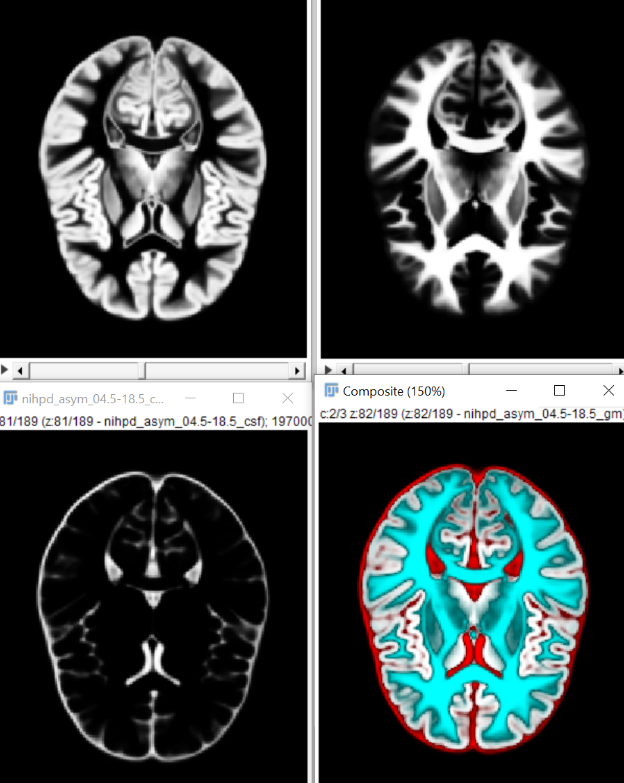

https://www.bic.mni.mcgill.ca/~vfonov/nihpd/obj1

In [1]:
!ls /gpfs_projects/brandon.nelson/pedsilicoICH/brain_atlases

nihpd_asym_04.5-18.5_csf.nii   nihpd_asym_04.5-18.5_t1w.nii
nihpd_asym_04.5-18.5_gm.nii    nihpd_asym_04.5-18.5_t2w.nii
nihpd_asym_04.5-18.5_mask.nii  nihpd_asym_04.5-18.5_wm.nii
nihpd_asym_04.5-18.5_pdw.nii   readme.txt


In [2]:
from pathlib import Path
base_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH/brain_atlases')

In [177]:
import nibabel as nib
csf = nib.load(base_dir / 'nihpd_asym_04.5-18.5_csf.nii').get_fdata().transpose(2, 1, 0)[:,::-1,:]
gm = nib.load(base_dir / 'nihpd_asym_04.5-18.5_gm.nii').get_fdata().transpose(2, 1, 0)[:,::-1,:]
wm = nib.load(base_dir / 'nihpd_asym_04.5-18.5_wm.nii').get_fdata().transpose(2, 1, 0)[:,::-1,:]
mask = nib.load(base_dir / 'nihpd_asym_04.5-18.5_mask.nii').get_fdata().transpose(2, 1, 0)[:,::-1,:]
pdw = nib.load(base_dir / 'nihpd_asym_04.5-18.5_pdw.nii').get_fdata().transpose(2, 1, 0)[:,::-1,:]

skull = (mask == 0)*pdw / pdw.max()
skull[skull < 0.1]=0

<OrthoSlicer3D: /gpfs_projects/brandon.nelson/pedsilicoICH/brain_atlases/nihpd_asym_04.5-18.5_pdw.nii (197, 233, 189)>

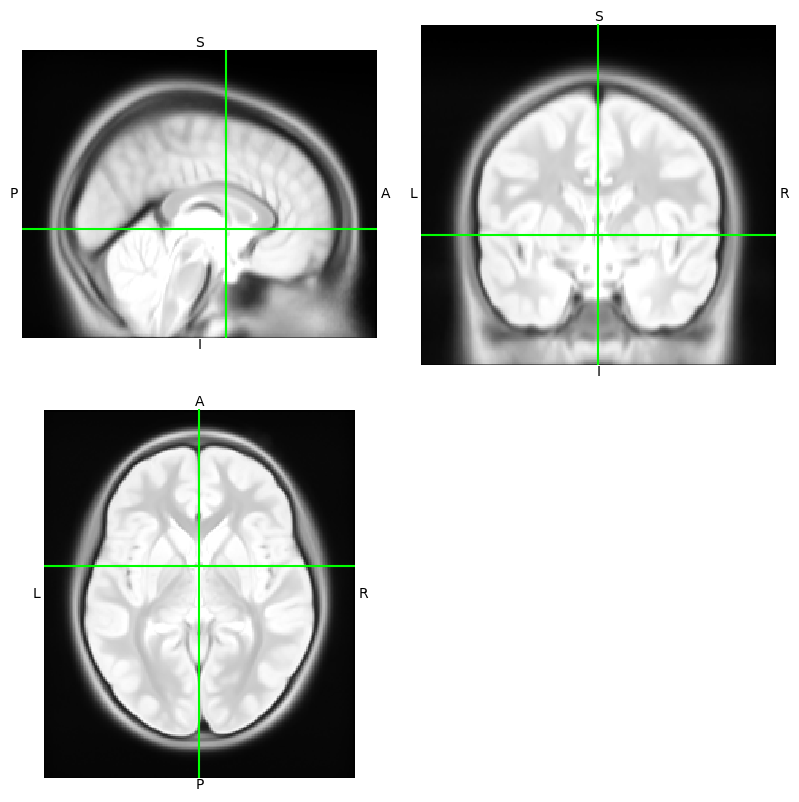

In [228]:
nib_img = nib.load(base_dir / 'nihpd_asym_04.5-18.5_pdw.nii')
nib_img.orthoview()

In [179]:
header = nib_img.header
dx, dy, dz = header['pixdim'][1:4]

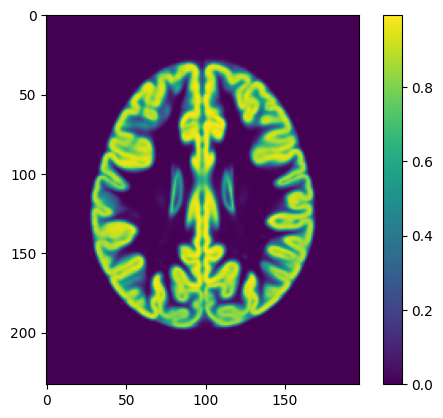

In [181]:
import matplotlib.pyplot as plt

plt.imshow(gm[100])
plt.colorbar()

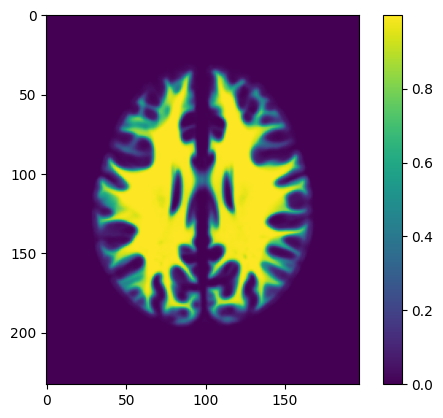

In [182]:
plt.imshow(wm[100])
plt.colorbar()

https://en.wikipedia.org/wiki/Hounsfield_scale

Note for pediatric brains the gray-white matter contrast is less due to less myelination so consider making wm_HU closer to gm_HU, maybe 30 or so

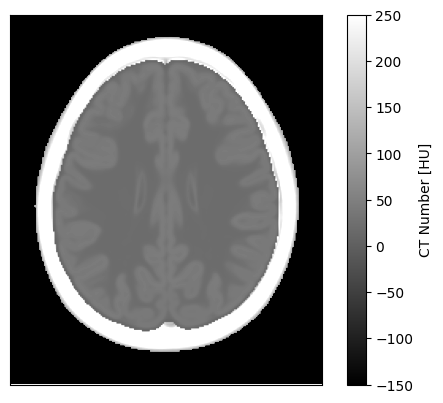

In [187]:
csf_HU = 15
gm_HU = 45
wm_HU = 20
skull_HU = 1000
air_HU = -1000

phantom = csf*csf_HU + gm*gm_HU + wm*wm_HU + skull*skull_HU
phantom[phantom==0] = -1000

from utils import ctshow
im = ctshow(phantom[100])
plt.colorbar(im, label='CT Number [HU]')

In [189]:
from utils import scrollview
scrollview(phantom)

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

## Try an Acquisition

In [190]:
from pedsilicoICH.image_acquisition import CTobj

In [191]:
ct = CTobj(phantom, spacings=(dz, dx, dy), patientname='pediatric brain atlas')

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'ICRU_adipose_adult2', 'water', 'ICRU_liver_adult', 'ICRU_skeleton_cortical_bone_adult']
* mu values (/cm): [0.05, 0.19, 0.21, 0.22, 0.6]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.16, 0.21, 0.23, 0.27]
* Thresholds (HU): [-1000.0, -200.0, 0.0, 100.0, 300.0]
*********************************************
* Calculating volume fraction maps for 5 materials and 189 slices...
* Writing volume fraction files for 5 materials an

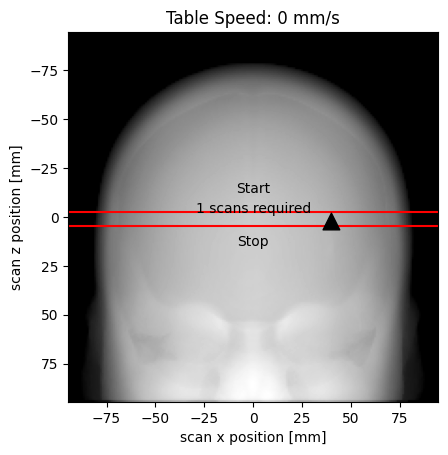

In [192]:
center = 0
width = 8

startZ = center - width//2
endZ = startZ + width
ct.scout_view(startZ=startZ, endZ=endZ)

In [193]:
ct.run_scan(mA=500, startZ=startZ, endZ=endZ, views=100)

scan: 1/1
Airscan
Offset scan
Phantom scan
phantom scan view loop...


  0%|                                                                                                                                                                                                                               | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated memory for image volume for material  5
in C> Copying data for material  5 into C memory...in C>  done.
in C> Allocated a total of    165 MB.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:30<00:00,  3.24it/s]

Prep view
Applying LSC...done.

Simulation is done.


<class 'pedsilicoICH.image_acquisition.CTobj'> default

In [194]:
ct.run_recon()

fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Writing the recon results to one big file...


<class 'pedsilicoICH.image_acquisition.CTobj'> default
Recon: (7, 512, 512) 25.0 cm fov
Projections: (100, 16, 900)

In [195]:
scrollview(ct.recon)

interactive(children=(IntSlider(value=3, description='idx', max=6), Output()), _dom_classes=('widget-interact'…

## Now add a lesion

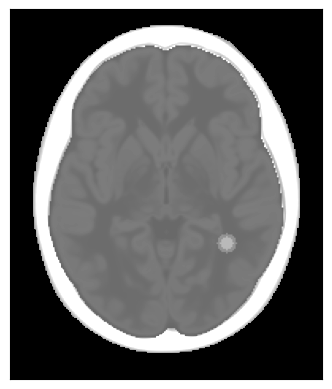

In [241]:
from pedsilicoICH.lesion_definition import spherical_lesion
from pedsilicoICH.lesion_insertion import add_random_sphere_lesion

contrast = [-20, 80]
radius = [6, 4]
ground_truth_image = phantom

brain_mask = wm > 0.3

img_w_lesion, lesion_image, lesion_coords = add_random_sphere_lesion(ground_truth_image, brain_mask, radius=radius, contrast=contrast)
z_loc = lesion_image.mean(axis=1).mean(axis=1).argmax()
ctshow(img_w_lesion[z_loc])

In [242]:
ct_lesion = CTobj(img_w_lesion, spacings=(dz, dx, dy), patientname='pediatric lesion')

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'ICRU_adipose_adult2', 'water', 'ICRU_liver_adult', 'ICRU_skeleton_cortical_bone_adult']
* mu values (/cm): [0.05, 0.19, 0.21, 0.22, 0.6]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.16, 0.21, 0.23, 0.27]
* Thresholds (HU): [-1000.0, -200.0, 0.0, 100.0, 300.0]
*********************************************
* Calculating volume fraction maps for 5 materials and 189 slices...
* Writing volume fraction files for 5 materials an

In [243]:
lesion_level_mm = (img_w_lesion.shape[0]/2 - lesion_coords[0])*dz
lesion_level_mm

np.float64(24.5)

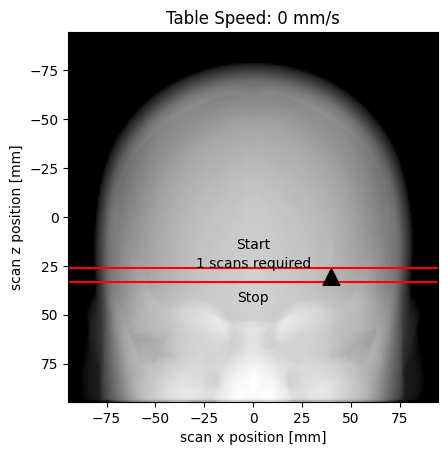

In [245]:
center = lesion_level_mm
width = 8

startZ = center - width//2
endZ = startZ + width

ct_lesion.scout_view(startZ=startZ, endZ=endZ)

In [246]:
ct_lesion.run_scan(mA=100, startZ=startZ, endZ=endZ)

scan: 1/1
Airscan
Offset scan
Phantom scan
phantom scan view loop...


  0%|                                                                                   | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated memory for image volume for material  5
in C> Copying data for material  5 into C memory...in C>  done.
in C> Allocated a total of    165 MB.


100%|████████████████████████████████████████████████████████████████████████| 1000/1000 [04:39<00:00,  3.58it/s]


Prep view
Applying LSC...done.

Simulation is done.


<class 'pedsilicoICH.image_acquisition.CTobj'> default

In [247]:
ct_lesion.run_recon()

fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Writing the recon results to one big file...


<class 'pedsilicoICH.image_acquisition.CTobj'> default
Recon: (7, 512, 512) 25.0 cm fov
Projections: (1000, 16, 900)

In [248]:
scrollview(ct_lesion.recon)

interactive(children=(IntSlider(value=3, description='idx', max=6), Output()), _dom_classes=('widget-interact'…

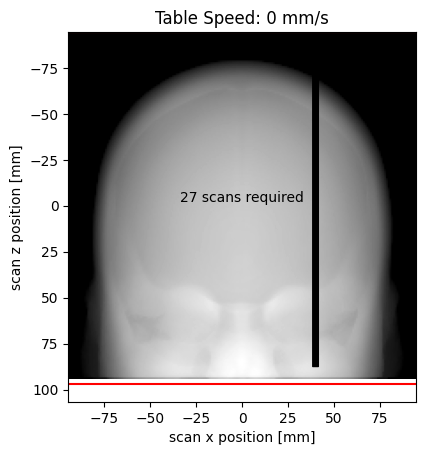

In [249]:
ct_lesion.scout_view()

In [ ]:
ct_lesion.run_scan(mA=100)

scan: 1/27
Airscan
Offset scan
Phantom scan
phantom scan view loop...


  0%|                                                                                   | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated memory for image volume for material  5
in C> Copying data for material  5 into C memory...in C>  done.
in C> Allocated a total of    165 MB.


100%|████████████████████████████████████████████████████████████████████████| 1000/1000 [03:23<00:00,  4.92it/s]


Prep view
Applying LSC...done.

Simulation is done.
scan: 2/27
Airscan
Offset scan
Phantom scan
phantom scan view loop...


...

100%|████████████████████████████████████████████████████████████████████████| 1000/1000 [04:41<00:00,  3.55it/s]


Prep view
Applying LSC...done.

Simulation is done.
scan: 3/27
Airscan
Offset scan
Phantom scan
phantom scan view loop...


  0%|                                                                                   | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated memory for image volume for material  5
in C> Copying data for material  5 into C memory...in C>  done.
in C> Allocated a total of    165 MB.


 17%|████████████▋                                                            | 174/1000 [00:49<03:56,  3.49it/s]

In [ ]:
ct_lesion.run_recon()

In [ ]:
scrollview(ct_lesion.recon)